In [14]:
from dotenv import load_dotenv
load_dotenv()

True

In [15]:
from langgraph.graph import START,END,StateGraph
from langgraph.graph.message import add_messages
from typing import Annotated
from langchain_groq import ChatGroq
from langchain_core.messages import HumanMessage
from pydantic import BaseModel

In [16]:
class chatState(BaseModel):
    msg : Annotated[list,add_messages]

In [17]:
llm = ChatGroq(
    model="openai/gpt-oss-20b"
)

In [18]:
def resp(state: chatState)->chatState:
    msg = state.msg
    res = llm.invoke(msg)
    state.msg = res
    
    return state

In [19]:
graph = StateGraph(chatState)

graph.add_node("resp",resp)

graph.add_edge(START,"resp")
graph.add_edge("resp",END)


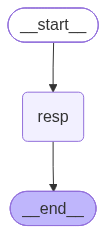

In [20]:
graph = graph.compile()
graph

In [21]:
res = graph.invoke({
    "msg":[ HumanMessage(content="Hi, how are you?")]
})


In [22]:
res

{'msg': [HumanMessage(content='Hi, how are you?', additional_kwargs={}, response_metadata={}, id='3461f1d8-3b5b-44f9-9697-4731b1a75a75'),
  AIMessage(content='Hello! I’m doing great—thanks for asking. How about you? Anything new or interesting on your end?', additional_kwargs={'reasoning_content': 'The user says "Hi, how are you?" This is a greeting. We can respond politely, ask how they are, maybe mention we are an AI. It\'s a simple conversation.'}, response_metadata={'token_usage': {'completion_tokens': 70, 'prompt_tokens': 77, 'total_tokens': 147, 'completion_time': 0.08430144, 'completion_tokens_details': {'reasoning_tokens': 38}, 'prompt_time': 0.003645357, 'prompt_tokens_details': None, 'queue_time': 0.315350721, 'total_time': 0.087946797}, 'model_name': 'openai/gpt-oss-20b', 'system_fingerprint': 'fp_d3e146e1a5', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--01a0cc2e-3b4c-7140-8089-46ff09ad8a39-0', tool_calls=[], 